This notebook demonstrates how to use `plot_pass_selection_embed` from `code/viz_pass_selection.py` to visualize pass selection predictions from a trained model with player embeddings.

In [26]:
import sys, os
import torch
import random
import numpy as np

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "code"))

from soccermap.statsbomb_io import load_events, load_threesixty, load_lineups
from soccermap.expand import build_expanded_dfs
from soccermap.dataset import PassDataset
from soccermap.model import SoccerMapWithPlayerEmbed, SoccerMapConfig
from viz_pass_selection import plot_pass_selection_embed

In [31]:
# ---- Load match data ----
checkpoint_name = "testing_with_new_stuff3.pt"
DATA_ROOT = os.path.join(PROJECT_ROOT, "data", "leverkusen_data")
MATCH_ID = "3895348"
# CKPT_PATH = os.path.join(PROJECT_ROOT, "checkpoints", "pass_selection_demo.pt")
CKPT_PATH = os.path.join(PROJECT_ROOT, "checkpoints", checkpoint_name)


events = load_events(DATA_ROOT, MATCH_ID)
threesixty = load_threesixty(DATA_ROOT, MATCH_ID)
lineups = load_lineups(DATA_ROOT, MATCH_ID)
m = build_expanded_dfs(events, threesixty, lineups)

ds = PassDataset(m.expanded_df, compute_velocities=False, only_passes=True, team_filter="Bayer Leverkusen")
print(f"Total pass samples: {len(ds)}")

Total pass samples: 676


In [32]:
ckpt = torch.load(CKPT_PATH, map_location="cpu")
player_id_mapping = ckpt["player_id_mapping"]

model = SoccerMapWithPlayerEmbed(
    num_players=ckpt["num_players"],
    embed_dim=ckpt["embed_dim"],
    context_dim=ckpt.get("context_dim", 0),
    context_hidden_dim=ckpt.get("context_hidden_dim", 16),
    context_embed_dim=ckpt.get("context_embed_dim", 8),
    cfg=SoccerMapConfig(),
)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Model loaded — {ckpt['num_players']} players, embed_dim={ckpt['embed_dim']}, context_dim={ckpt.get('context_dim', 0)}")


Model loaded — 29 players, embed_dim=8, context_dim=9


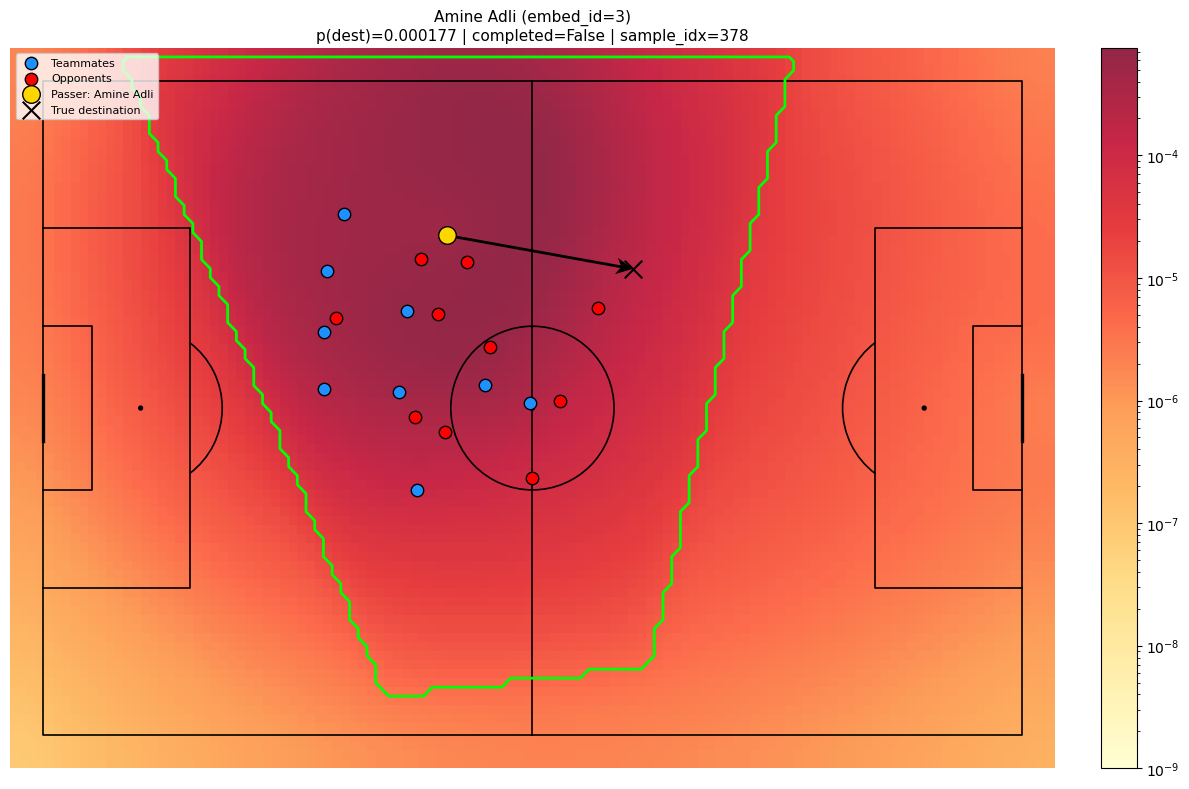

In [33]:

plot_pass_selection_embed(
    model, ds, m.expanded_df, player_id_mapping,
    sample_idx=378,
);

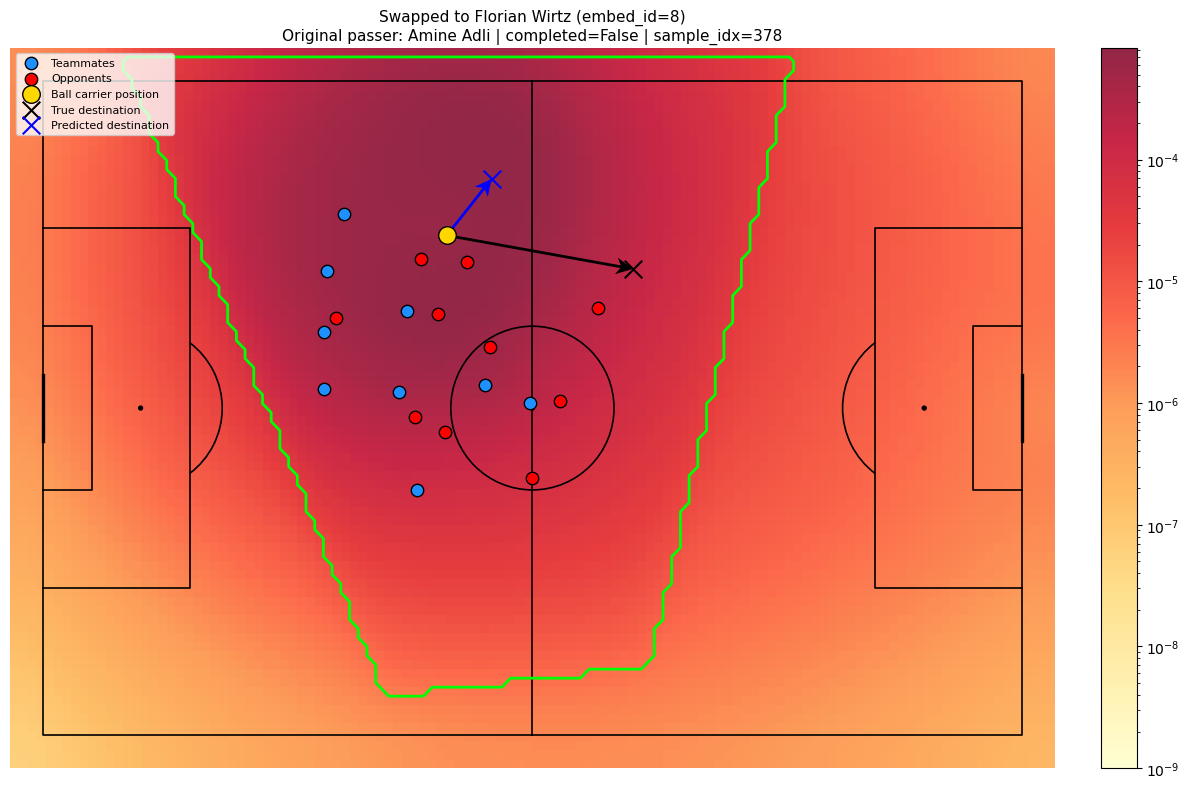

In [34]:
# SWAP_PLAYER = "Amine Adli"
SWAP_PLAYER = "Granit Xhaka"
# SWAP_PLAYER = "Jonathan Tah"
SWAP_PLAYER = "Florian Wirtz"
SWAP_PLAYER = "Exequiel Palacios"
# all possible players in Bayer Leverkusen from the dataset

wirtz, wirtz_prob = plot_pass_selection_embed(
    model, ds, m.expanded_df, player_id_mapping,
    sample_idx = 378,
    swap_player = "Florian Wirtz"
)

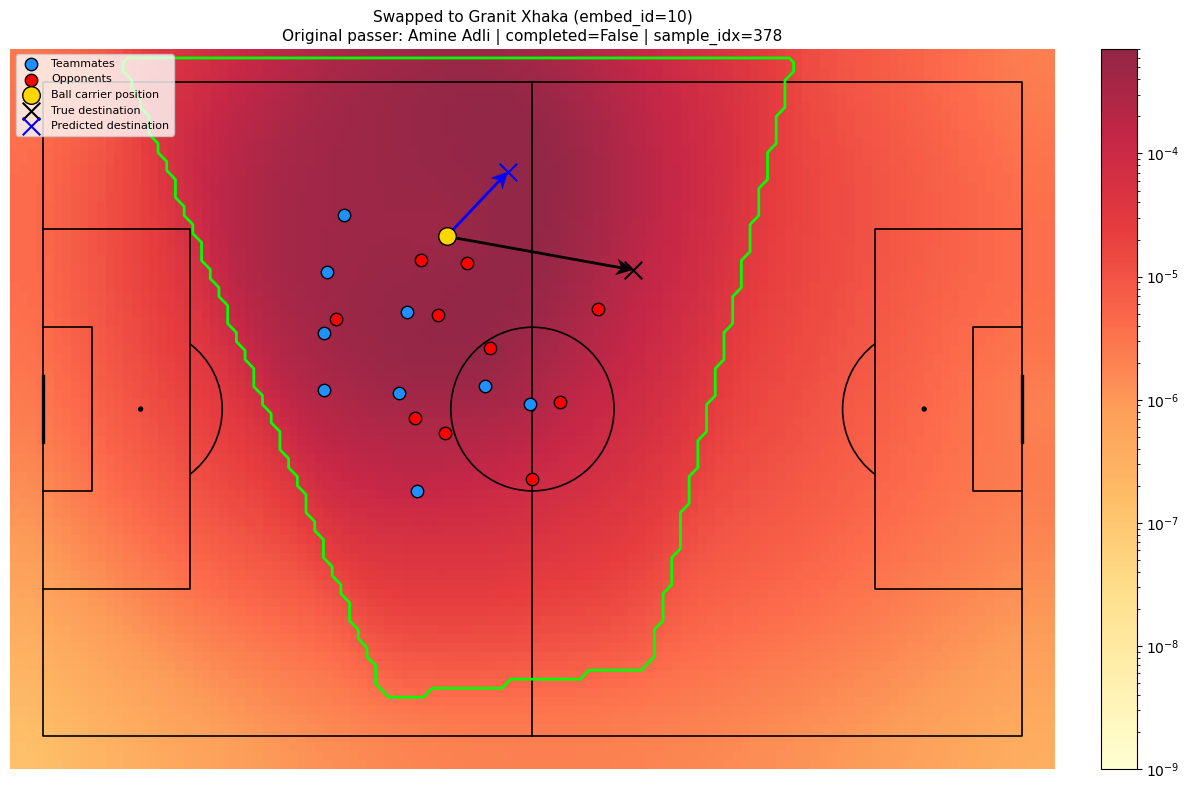

In [35]:
xhaka, xhaka_prob = plot_pass_selection_embed(
    model, ds, m.expanded_df, player_id_mapping,
    sample_idx = 378,
    swap_player = "Granit Xhaka"
)

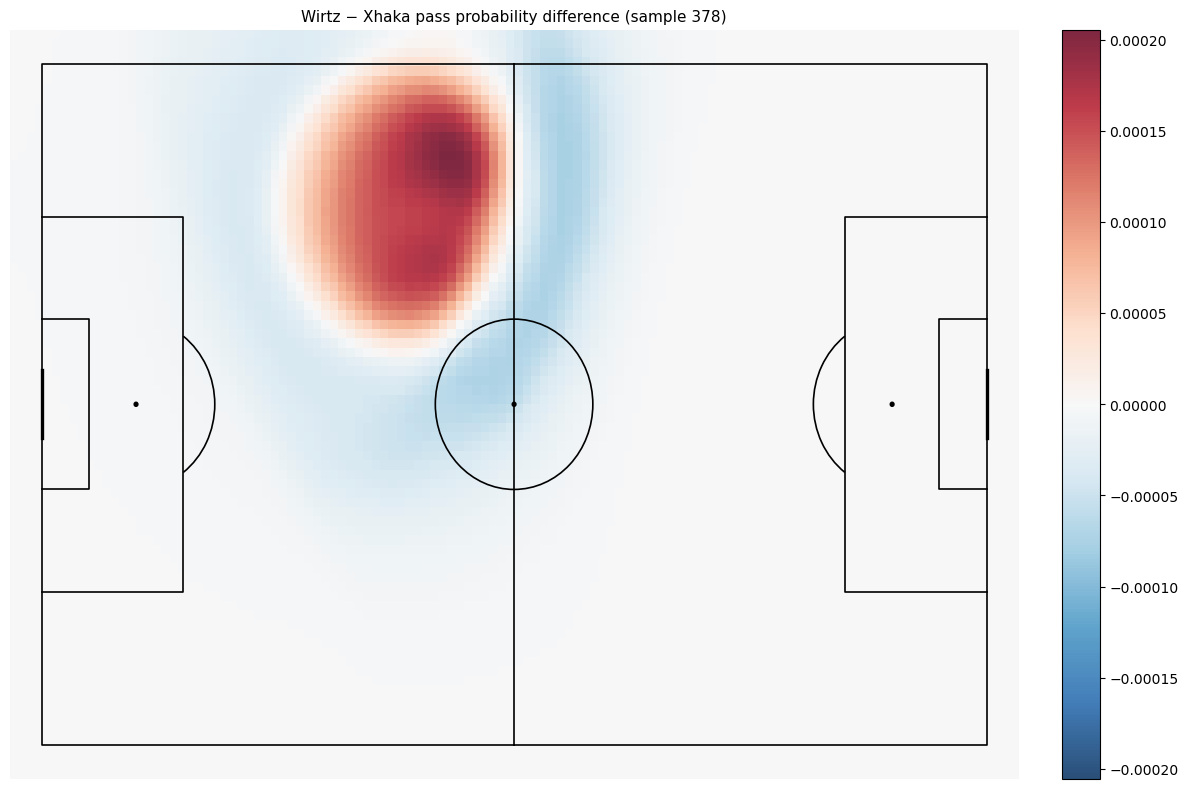

In [36]:
diff = wirtz_prob - xhaka_prob  # numpy array, same shape as the grid

# Plot the difference
from soccermap.viz import _to_img_yx
from mplsoccer import Pitch
from matplotlib import pyplot as plt
img_diff = _to_img_yx(diff)

pitch = Pitch(pitch_type="statsbomb", line_color="black", linewidth=1.2)
fig, ax = pitch.draw(figsize=(12, 8))

vmax = np.max(np.abs(img_diff))
im = ax.imshow(
    img_diff,
    extent=pitch.extent,
    origin="upper",
    aspect="auto",
    cmap="RdBu_r",  # red = Wirtz higher, blue = Xhaka higher
    vmin=-vmax, vmax=vmax,
    alpha=0.85,
)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Wirtz − Xhaka pass probability difference (sample 378)", fontsize=11)
plt.show()


In [29]:
# find a difference between the two plots (wirtz vs xhaka) 
difference = wirtz - xhaka
print("Difference between Wirtz and Xhaka plots:", difference)


TypeError: unsupported operand type(s) for -: 'Figure' and 'Figure'